# Logistic Regression

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Logistic Regression
from sklearn.linear_model import LogisticRegression
# Import Feature Scaling Package
from sklearn.preprocessing import StandardScaler
# Import train test split package
from sklearn.model_selection import train_test_split
# Import classification metrics
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,roc_auc_score

In [2]:
df = pd.read_csv('Dataset/Cardiovascular_Disease.csv')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [3]:
df['age']=(df['age']//365)

In [4]:
df = df[
    (df['height'].between(145,185))&
    (df['weight'].between(45,120))&
    (df['ap_hi'].between(90,200))&
    (df['ap_lo'].between(50,90))
]
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
4,4,47,1,156,56.0,100,60,1,1,0,0,0,0
5,8,60,1,151,67.0,120,80,2,2,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69994,99992,57,1,165,80.0,150,80,1,1,0,0,1,1
69995,99993,52,2,168,76.0,120,80,1,1,1,0,1,0
69997,99996,52,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61,1,163,72.0,135,80,1,2,0,0,0,1


### Features and Target

In [5]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

In [6]:
features =['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active']

target = 'cardio'

In [7]:
X = df[features]
Y = df[target]
X

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active
0,50,2,168,62.0,110,80,1,1,0,0,1
1,55,1,156,85.0,140,90,3,1,0,0,1
2,51,1,165,64.0,130,70,3,1,0,0,0
4,47,1,156,56.0,100,60,1,1,0,0,0
5,60,1,151,67.0,120,80,2,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...
69994,57,1,165,80.0,150,80,1,1,0,0,1
69995,52,2,168,76.0,120,80,1,1,1,0,1
69997,52,2,183,105.0,180,90,3,1,0,1,0
69998,61,1,163,72.0,135,80,1,2,0,0,0


### Train Test Split


In [8]:
X_train, X_test, Y_train , Y_test = train_test_split(X,Y, test_size=0.2,random_state=42,stratify=Y)

### Feature Scaling

In [9]:
scalar=StandardScaler()
X_train_scale = scalar.fit_transform(X_train)
X_test_scale=scalar.transform(X_test)


### Define Model

In [10]:
model = LogisticRegression(solver='lbfgs',class_weight='balanced',random_state=42)
model.fit(X_train_scale,Y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [11]:
Y_pred = model.predict(X_test_scale)
Y_pred

array([1, 1, 0, ..., 0, 0, 0], shape=(12457,))

### metrics

In [12]:
cr = classification_report(Y_test,Y_pred)
cm = confusion_matrix (Y_test,Y_pred)

In [13]:
print('Classification Report')
print('-'*35)
print(cr)

Classification Report
-----------------------------------
              precision    recall  f1-score   support

           0       0.72      0.76      0.74      6631
           1       0.71      0.67      0.69      5826

    accuracy                           0.72     12457
   macro avg       0.72      0.72      0.72     12457
weighted avg       0.72      0.72      0.72     12457



In [14]:
'''
Macro Avg
     -Metric1 + Metric 2 + ......... + Metric_n /n


Weighted Avg
    -support1 * metric 1 + support 2 metric 2 + ----------+ support_n + total support


'''
# weighted_avg = ((6631*0.72)+(5826*0.71))/12457
# weighted_avg

'\nMacro Avg\n     -Metric1 + Metric 2 + ......... + Metric_n /n\n\n\nWeighted Avg\n    -support1 * metric 1 + support 2 metric 2 + ----------+ support_n + total support\n\n\n'

In [15]:
print("Confusion Matrix")
print('-'*35)
print(cm)

Confusion Matrix
-----------------------------------
[[5071 1560]
 [1947 3879]]


In [16]:
'''
True Positive -> 5071
False Negative -> 1560
False Positive -> 1947
True Negative -> 3879

'''

'\nTrue Positive -> 5071\nFalse Negative -> 1560\nFalse Positive -> 1947\nTrue Negative -> 3879\n\n'

### ROC AUC Curve

In [ ]:
'''
threshold
    - Default = 0.5
    - 


    
'''


'''
Email spam detection

Threshold -> 0.5

TPR -> True Positive Rate
    -TP / (TP - FN)

FPR -> False Positive Rate
    -FP / (FP -  TN)

JScore ->  Best Threshold Position Find. (TPR - FPR)
 
'''

'\nthreshold\n    - Default = 0.5\n    - \n\n'

In [21]:
#Ca;culation of Probability
Y_prob =  model.predict_proba(X_test_scale)[:,1]
Y_prob

array([0.84512037, 0.68994548, 0.2019743 , ..., 0.45036942, 0.48449602,
       0.4805284 ], shape=(12457,))

In [ ]:
## Convert Confusion matrix data to one dimension using ravel
tn,fp,fn,tp = cm.ravel()

#calculate True positive Rate and False Positive Rate

tpr_default = tp / (tp - fn)
fpr_default = fp / (fp - tn)

print(f'True Positive Rate : {tpr_default}')
print(f'False Positive Rate: {fpr_default}') 

True Positive Rate : 2.0077639751552794
False Positive Rate: -0.44431785816006836


In [53]:
## Find ROC Curve and ROC AUC Score data

fpr, tpr, threshold = roc_curve(Y_test, Y_prob)
auc_score = roc_auc_score(Y_test, Y_prob)

print(f'ROC False Positive Rate: {fpr}')
print(f'ROC True Positive Rate: {tpr}')
print(f'ROC Threshold: {threshold}')

ROC False Positive Rate: [0.         0.         0.         ... 0.99819032 0.99819032 1.        ]
ROC True Positive Rate: [0.00000000e+00 1.71644353e-04 5.14933059e-04 ... 9.99828356e-01
 1.00000000e+00 1.00000000e+00]
ROC Threshold: [       inf 0.99742597 0.9957539  ... 0.03431086 0.03409424 0.02431706]


In [54]:
#Calculate JScore for best threshold positions

j_score = tpr - fpr

best_idx = np.argmax(j_score)

best_tpr = tpr[best_idx]
best_fpr = fpr[best_idx]
best_threshold = threshold[best_idx]

print(f'Best Index: {best_idx}')
print(f'Best True Positive Rate: {best_tpr}')
print(f'Best False Positive Rate: {best_fpr}')
print(f'Best Threshold: {best_threshold}')

Best Index: 2099
Best True Positive Rate: 0.6752488843117062
Best False Positive Rate: 0.24370381541245664
Best Threshold: 0.493649324237761


### ROC AUC Curve Visualization

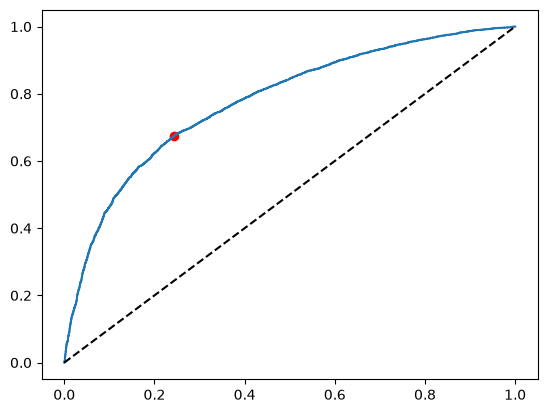

In [76]:
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'k--')
plt.scatter(best_fpr,best_tpr,color='RED')
plt.show()

In [64]:
## Calculation of probability of new threshold

Y_prob_opt = (Y_prob >= best_threshold).astype(int)
Y_prob_opt

array([1, 1, 0, ..., 0, 0, 0], shape=(12457,))

In [65]:
new_cr = classification_report(Y_test, Y_prob_opt)
new_cm = confusion_matrix(Y_test, Y_prob_opt)

In [71]:
print(new_cr)

              precision    recall  f1-score   support

           0       0.73      0.76      0.74      6631
           1       0.71      0.68      0.69      5826

    accuracy                           0.72     12457
   macro avg       0.72      0.72      0.72     12457
weighted avg       0.72      0.72      0.72     12457



In [72]:
print(new_cm)

[[5015 1616]
 [1892 3934]]


<Axes: >

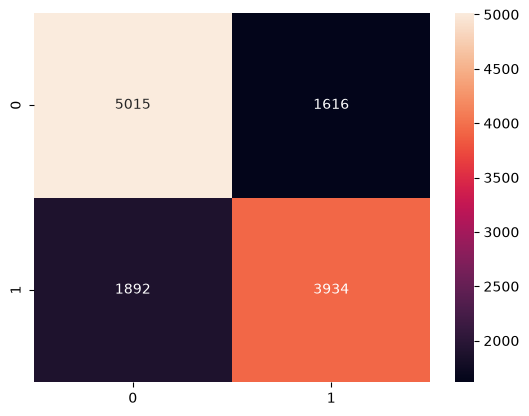

In [75]:
sns.heatmap(new_cm, annot=True, fmt='0.0f')